## ALMA Mock Observations

---

### SIMALMA: CASA simulation task

- Download CASA: https://casa.nrao.edu/
- Simulations including $uv$-coverage, PSF, dirty image, residuals, fidelity maps
- `simalma` documentation: https://casadocs.readthedocs.io/en/stable/api/tt/casatasks.simulation.simalma.html
- Examples of use: https://casaguides.nrao.edu/index.php/Simalma_(CASA_5.1)
- Array configuration files: https://almascience.nrao.edu/tools/casa-simulator


### ALMA Observation Support Tool (OST)

- Web-based alternative to CASA simulations
- `ALMA-OST`: https://almaost.jb.man.ac.uk/
- Reference paper: https://arxiv.org/abs/1106.3516
- Example of use: https://arxiv.org/abs/2101.11013


### Python-based simulations (Astropy)

- Build a sky model image for `simalma`
- Mimic ALMA observing parameters

---

In [1]:
from IPython.core.display import HTML
HTML('''<script>
code_show=true;
function code_toggle() {
    if (code_show){
        $('div.input').hide();
    } else {
        $('div.input').show();
    }
    code_show = !code_show
}
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Show / hide code"></form>''')

## Simulating ALMA data in Python

Minimal code blocks to get started (you could easily refine/adapt them to your work using any AI tool)

In [2]:
# Used packages and versions
import astropy
import matplotlib
import numpy as np
import scipy
print({m.__name__: m.__version__ for m in [astropy, matplotlib, np, scipy]})

from astropy.io import fits
from astropy.wcs import WCS
from astropy.convolution import convolve, convolve_fft, Gaussian2DKernel
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.ndimage import gaussian_filter

{'astropy': '5.2.2', 'matplotlib': '3.7.0', 'numpy': '1.24.0', 'scipy': '1.14.1'}


### 1. Create a Sky Model Image for SIMALMA

#### 1.1. Simple 2D Gaussian

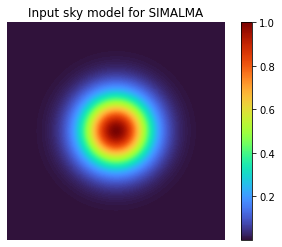

In [3]:
npix = 512 #default model image size in SIMALMA
Y,X = np.indices((npix,npix)) #2D map
x0,y0 = npix/2,npix/2 #source center == 2D map center

n = 3.5 #source extension
model = np.exp(-((X-x0)**2+(Y-y0)**2)/(2*10**n)) #2D Gaussian

plt.imshow(model,origin='lower',cmap='turbo')
plt.title('Input sky model for SIMALMA')
plt.axis('off')
plt.colorbar()
plt.show()
#fits.writeto('skymodel.fits', model.astype(np.float32), overwrite=True) #save to FITS

#### 1.2. Advanced sky model: protoplanetary disk

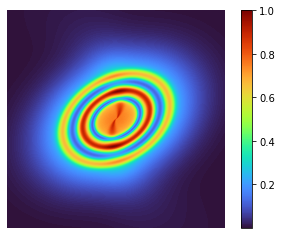

In [4]:
npix = 512
Y,X = np.indices((npix,npix)) #2D map
x0,y0 = npix/2,npix/2 #center
dx = X-x0
dy = Y-y0

# disk shape parameters
i  = np.deg2rad(45) #inclination
pa = np.deg2rad(30) #position angle
xp = dx*np.cos(pa) + dy*np.sin(pa)
yp = (-dx*np.sin(pa) + dy*np.cos(pa)) /np.cos(i)

# from cartesian to polar coords:
R = np.sqrt(xp**2 + yp**2)
TH = np.arctan2(yp,xp)

# diffuse disk emission
disk_amp = .5 #intensity
disk_sc = 100 #scale
model2 = disk_amp * np.exp(-(R**2) / (2*disk_sc**2))

# adding bright rings
ring1 = .25 * np.exp(-((R-85)**2) / (2*7**2))
ring2 = .24 * np.exp(-((R-135)**2) / (2*9**2))
model2 += ring1+ring2 #+ring3

# adding emission gaps
gap1 = 1-.8 * np.exp(-((R-60)**2) / (2*6**2))
gap2 = 1-.7 * np.exp(-((R-110)**2) / (2*8**2))
model2 *= gap1*gap2

# central feature
spiral_amp = .12
spiral_width = .2
for k in range(2):
    spiral = np.mod(TH-.25*np.log(R+1) - k*np.pi+np.pi, 2*np.pi) - np.pi
    model2 += spiral_amp * np.exp(-(spiral**2) / (2*spiral_width**2)) * np.exp(-R/140)

model2 /= model2.max() #normalize flux

plt.imshow(model2,origin='lower',cmap='turbo')
plt.axis('off')
plt.colorbar()
plt.show()
# fits.writeto('skymodel_protodisk.fits', model2.astype(np.float32), overwrite=True)

#### 1.3. Advanced sky model: spiral galaxy

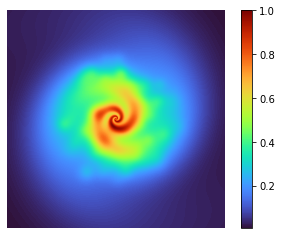

In [5]:
npix = 512
Y,X = np.indices((npix,npix)) #2D map
x0,y0 = npix/2,npix/2 #center

# from cartesian to polar coords:
R = np.sqrt((X-x0)**2 + (Y-y0)**2)
TH = np.arctan2(Y-y0, X-x0)

# galaxy extension
galsize = 120

# galaxy bulge
bulge_amp = .5
bulge_sigma = .75*galsize
model3 = bulge_amp *np.exp(-R**2/(2*bulge_sigma**2))

# spiral arm features
n_arms = 2 #number
arm_i = .5 #intensity
arm_w = .8 #width
arm_c = .4 #compactness

for k in range(n_arms):
    theta_arm = TH - k * 2*np.pi / n_arms
    spiral = np.mod(theta_arm - np.log(R+1) / arm_c+np.pi, 2*np.pi) -np.pi
    arm_mask = np.exp(-(spiral**2) / (2*arm_w**2))
    radial_taper = np.exp(-R/galsize)
    model3 += arm_i * arm_mask * radial_taper

n_clumps = 100
# np.random.seed(999) #uncomment to fix sky model appearance
angles = np.random.uniform(0,2*np.pi,n_clumps)
# clumps location range (in radii):
r_spiral = np.random.uniform(.1*galsize,1.25*galsize,n_clumps)

for a,r in zip(angles,r_spiral):
    arm_offset = np.random.normal(0,1)
    theta = a+np.log(r+1)
    xc = x0 + (r+arm_offset) * np.cos(theta)
    yc = y0 + (r+arm_offset) * np.sin(theta)
    dx, dy = X-xc, Y-yc
    amp = np.random.uniform(.02,.05) #clumps intensity
    sigma = np.random.uniform(10,15) #smoothness
    model3 += amp * np.exp(-(dx**2+dy**2) / (2*sigma**2))

model3 /= model3.max() #normalize flux

plt.imshow(model3,origin='lower',cmap='turbo')
plt.axis('off')
plt.colorbar()
plt.show()
# fits.writeto('skymodel_spiral.fits', model2.astype(np.float32), overwrite=True)

You may also use GALFIT to fit 2D galaxy surface brightness profiles to your data (e.g., Peng et al. 2002, 2010). <br>
Reference papers: https://arxiv.org/abs/astro-ph/0204182 and https://arxiv.org/abs/0912.0731

#### 1.4. Advanced sky model: Einstein ring

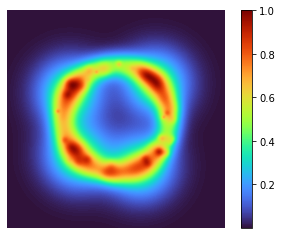

In [6]:
npix = 512
Y,X = np.indices((npix,npix)) #2D map
x0,y0 = npix/2,npix/2 #center

# from cartesian to polar coords:
R = np.sqrt((X-x0)**2 + (Y-y0)**2)

# diffuse ring-like emission
ring_r = 125 #radius
ring_t = 20  #thickness
amp = .3     #intensity
diffuse_ring = amp * np.exp(-((R-ring_r)**2) / (2*ring_t**2))
model4 = diffuse_ring.copy()

# adding four lensed images
angles = [300.5,305.5,310.5,51]
for i in angles:
    xc = x0 + ring_r * np.cos(i)
    yc = y0 + ring_r * np.sin(i)
    dx,dy = X-xc, Y-yc
    amp = .3 #intensity
    model4 += amp * np.exp(-(dx**2+dy**2) / (2*50**2))

# adding many small clumps
n_clumps = 50
#np.random.seed(999) #uncomment to fix sky model appearance
angles = np.random.uniform(0,2*np.pi,n_clumps)
smooth = np.random.normal(0,10,n_clumps)

for a, dr in zip(angles, smooth):
    xc = x0 + (ring_r+dr) *np.cos(a)
    yc = y0 + (ring_r+dr) *np.sin(a)
    dx,dy = X-xc, Y-yc
    amp = np.random.uniform(.01,.1)
    sigma = np.random.uniform(3,15)
    model4 += amp * np.exp(-(dx**2+dy**2) / (2*sigma**2))

model4 /= model4.max() #normalize flux

plt.imshow(model4,origin='lower',cmap='turbo')
plt.axis('off')
plt.colorbar()
plt.show()
#fits.writeto('skymodel_ring.fits', model.astype(np.float32), overwrite=True)

### 2. Simulate ALMA observations

#### 2.1. Beam convolution

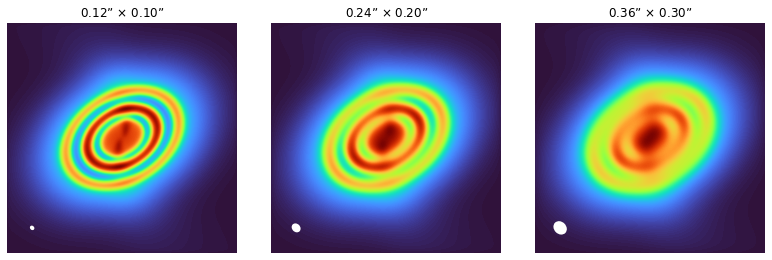

In [7]:
# An example using the protoplanetary disk sky model
npix = 512
px = .01 #change to match your pixel arsec scale

Y,X = np.indices((npix,npix)) #2D map
x0,y0 = npix/2,npix/2 #center
dx = X-x0
dy = Y-y0

# Protodisk model (see Sect. 1.2.)
i  = np.deg2rad(45) #inclination
pa = np.deg2rad(30) #position angle
xp = dx *np.cos(pa) + dy *np.sin(pa)
yp = (-dx *np.sin(pa) + dy *np.cos(pa)) /np.cos(i)

R = np.sqrt(xp**2 + yp**2)
TH = np.arctan2(yp,xp)

disk_amp = .5 #intensity
disk_sc = 100 #scale
model2 = disk_amp * np.exp(-(R**2) / (2*disk_sc**2))

ring1 = .25 * np.exp(-((R-85)**2) / (2*7**2))
ring2 = .24 * np.exp(-((R-135)**2) / (2*9**2))
model2 += ring1+ring2 #+ring3

gap1 = 1-.8 * np.exp(-((R-60)**2) / (2*6**2))
gap2 = 1-.7 * np.exp(-((R-110)**2) / (2*8**2))
model2 *= gap1*gap2

spiral_amp = .12
spiral_width = .2
for k in range(2):
    spiral = np.mod(TH-.25 * np.log(R+1) - k*np.pi+np.pi, 2*np.pi) - np.pi
    model2 += spiral_amp * np.exp(-(spiral**2) / (2*spiral_width**2)) * np.exp(-R/140)

model2 /= model2.max() #norm


# Synthesized beam
f2s = 1/(2*np.sqrt(2*np.log(2)))
pa_deg = 45 #position angle

# Comparison of different angular resolutions
fig, axes = plt.subplots(1,3, figsize=(11,3.5), constrained_layout=True)
resolutions = [(.12,.1),(.24,.2),(.36,.3)]
titles = [r'0.12” $\times$ 0.10”',r'0.24” $\times$ 0.20”',r'0.36” $\times$ 0.30”']
im = None
base_model2 = model2.copy()

for ax,(fwhm_maj,fwhm_min),t in zip(axes,resolutions,titles):
    sigma_maj_pix = (fwhm_maj/px)*f2s
    sigma_min_pix = (fwhm_min/px)*f2s
    kernel = Gaussian2DKernel(x_stddev=sigma_min_pix, y_stddev=sigma_maj_pix, theta=np.deg2rad(pa_deg))
    kernel.normalize()
    model2 = convolve_fft(base_model2, kernel, boundary='fill', fill_value=0, allow_huge=True, preserve_nan=True)
    model2 /= np.nanmax(model2)
    im = ax.imshow(model2, origin='lower', cmap='turbo')
    ax.add_patch(Ellipse((55,55), width=.9*fwhm_min/px, height=.9*fwhm_maj/px, angle=pa_deg, edgecolor='w', facecolor='w', lw=0))
    ax.axis('off')
    ax.set_title(t)
    
plt.show()

#### 2.2. Interferometric noise

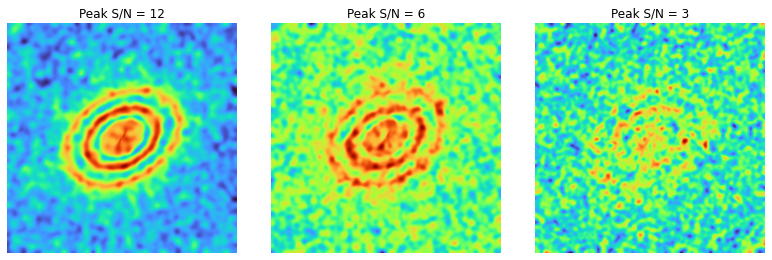

In [8]:
# An example using the protoplanetary disk sky model
npix = 512
Y,X = np.indices((npix,npix)) #2D map
x0,y0 = npix/2,npix/2 #center
dx = X-x0
dy = Y-y0

# Protodisk model (see Sect. 1.2.)
i  = np.deg2rad(45) #inclination
pa = np.deg2rad(30) #position angle
xp = dx * np.cos(pa) + dy * np.sin(pa)
yp = (-dx * np.sin(pa) + dy * np.cos(pa)) / np.cos(i)

R = np.sqrt(xp**2 + yp**2)
TH = np.arctan2(yp,xp)

disk_amp = .5 #intensity
disk_sc = 100 #scale
model2 = disk_amp * np.exp(-(R**2) / (2*disk_sc**2))

ring1 = .25 * np.exp(-((R-85)**2) / (2*7**2))
ring2 = .24 * np.exp(-((R-135)**2) / (2*9**2))
model2 += ring1+ring2 #+ring3

gap1 = 1-.8 * np.exp(-((R-60)**2) / (2*6**2))
gap2 = 1-.7 * np.exp(-((R-110)**2) / (2*8**2))
model2 *= gap1*gap2

spiral_amp = .12
spiral_width = .2
for k in range(2):
    spiral = np.mod(TH-.25 * np.log(R+1) - k*np.pi+np.pi, 2*np.pi) - np.pi
    model2 += spiral_amp * np.exp(-(spiral**2) / (2*spiral_width**2)) * np.exp(-R/140)

model2 /= model2.max() #norm


# Comparison of different noise levels
fig, axes = plt.subplots(1,3, figsize=(11,3.5), constrained_layout=True)
SNRs = [12,6,3]  #signal-to-noise @FWHM
sigmas = [6,5,4] #clumpiness
im = None
base_model2 = model2.copy()

for ax,snr,sig in zip(axes,SNRs,sigmas):
    raw = np.random.normal(loc=0,scale=1,size=base_model2.shape)
    ns = gaussian_filter(raw,sigma=sig) #noise
    ns /= np.nanstd(ns)
    rms = np.nanmax(base_model2)/snr #np.mean(base_model2)/snr
    ns*=rms
    model2 = base_model2+ns
    im = ax.imshow(model2,origin='lower',cmap='turbo')
    ax.axis('off')
    ax.set_title(rf'Peak S/N = {snr}')

plt.show()

You may adjust the noise parameters to match the expected S/N ratio from the Observing Tool (OT) in the normalized sky model. In the OT, the S/N depends on the requested rms sensitivity, angular and spectral resolutions, and the peak flux density per synthesized beam. <br>

To estimate the peak flux density per synthesized beam for the Observing Tool, see: <br>
https://help.almascience.org/kb/articles/how-can-i-estimate-the-peak-flux-density-per-synthesised-beam-using-flux-measurements-in-jy-or

#### 2.3. Mock observed maps (beam + noise)

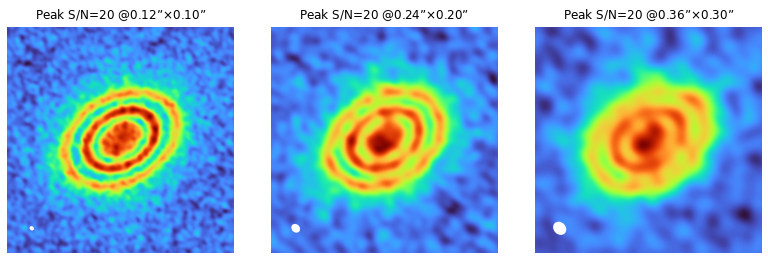

In [9]:
# Models combining AR and S/R
npix = 512
px = 0.01 #pixel scale

Y,X = np.indices((npix,npix)) #2D map
x0,y0 = npix/2,npix/2 #center
dx = X-x0
dy = Y-y0

# Protodisk model (see Sect. 1.2.)
i  = np.deg2rad(45) #inclination
pa = np.deg2rad(30) #position angle
xp = dx * np.cos(pa) + dy * np.sin(pa)
yp = (-dx * np.sin(pa) + dy * np.cos(pa)) / np.cos(i)

R = np.sqrt(xp**2 + yp**2)
TH = np.arctan2(yp,xp)

disk_amp = .5 #intensity
disk_sc = 100 #scale
model2 = disk_amp * np.exp(-(R**2) / (2*disk_sc**2))

ring1 = .25 * np.exp(-((R-85)**2) / (2*7**2))
ring2 = .24 * np.exp(-((R-135)**2) / (2*9**2))
model2 += ring1+ring2

gap1 = 1-.8 * np.exp(-((R-60)**2) / (2*6**2))
gap2 = 1-.7 * np.exp(-((R-110)**2) / (2*8**2))
model2 *= gap1*gap2

spiral_amp = .12
spiral_width = .2
for k in range(2):
    spiral = np.mod(TH-.25 * np.log(R+1) - k*np.pi+np.pi, 2*np.pi) -np.pi
    model2 += spiral_amp * np.exp(-(spiral**2) / (2*spiral_width**2)) * np.exp(-R/140)

model2 /= model2.max() #norm


# Synthesized beam
f2s = 1/(2*np.sqrt(2*np.log(2)))
pa_deg = 45 #position angle

# Comparison of different angular resolutions
fig, axes = plt.subplots(1,3, figsize=(11,3.5), constrained_layout=True)
resolutions = [(.12,.1),(.24,.2),(.36,.3)]
peak_snrs = [20,20,20]
titles = [r'0.12”$\times$0.10”',
          r'0.24”$\times$0.20”',
          r'0.36”$\times$0.30”']
im = None
base_model2 = model2.copy()
rng = np.random.default_rng(42)

for ax,(fwhm_maj,fwhm_min),snr_peak,t in zip(axes,resolutions,peak_snrs,titles):
    sigma_maj_pix = (fwhm_maj/px)*f2s
    sigma_min_pix = (fwhm_min/px)*f2s
    kernel = Gaussian2DKernel(x_stddev=sigma_min_pix, y_stddev=sigma_maj_pix, theta=np.deg2rad(pa_deg))
    kernel.normalize()

    model2 = convolve_fft(base_model2, kernel, boundary='fill', fill_value=0.0, allow_huge=True, preserve_nan=True)
    model2 /= np.nanmax(model2)

    raw = rng.normal(loc=0, scale=1, size=base_model2.shape)
    noise = convolve_fft(raw, kernel, boundary='fill', fill_value=0.0, allow_huge=True, preserve_nan=True)
    noise /= np.nanstd(noise)

    rms = np.nanmax(model2) / snr_peak
    model2 = model2 + rms*noise

    im = ax.imshow(model2, origin='lower', cmap='turbo')
    ax.add_patch(Ellipse((55,55), width=.9*fwhm_min/px, height=.9*fwhm_maj/px, angle=pa_deg, edgecolor='w', facecolor='w', lw=0))
    ax.axis('off')
    ax.set_title(rf'Peak S/N={snr_peak} @{t}', pad=8)

plt.show()

---
Mock data tutorial for ALMA workshops (C. Cornil-Baïotto) | Contact: carla.cornil@postgrado.uv.cl